# Scholarly Article Recommendation System

This notebook implements a scholarly article recommendation framework using:

- TF-IDF cosine similarity (abstract-only, matches `classification_pipeline.ipynb`)
- Logistic Regression probability re-ranking
- Information Retrieval evaluation metrics

Evaluation Metrics:
- Precision@K
- Recall@K
- MAP@K
- NDCG@K
- MRR

For every test article we treat it as a query and rank all training articles by similarity, then evaluate top-$k$ retrieval. Two ranking strategies are compared:

- **Method A** Pure cosine similarity over abstract-only TF-IDF vectors.
- **Method B** Cosine similarity re-weighted by the trained Logistic Regression's class probabilities.

Same-class-as-query is the relevance proxy.

## Imports and NLTK setup

In [12]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

for r in ("stopwords", "punkt", "punkt_tab", "wordnet"):
    try: nltk.download(r, quiet=True)
    except Exception: pass

## Dataset Configuration

In [13]:
DATA_DIR = r"C:\Users\ghazi.irfan\Desktop\ieee-xplore-classification\data"
DOMAIN_STOPS = {
    "data", "system", "paper", "model", "approach", "method", "proposed",
    "result", "results", "analysis", "processing", "framework", "based",
    "show", "shown", "study", "research", "performance", "different",
    "presented", "novel", "introduce", "introduces", "discussed",
    "use", "using", "used", "provides", "provided", "develop", "developed",
}
ALL_STOPS = set(stopwords.words("english")) | DOMAIN_STOPS
LEM = WordNetLemmatizer()
SYM = re.compile(r"[!\"#$%&()*,+\-./:;<=>?@\[\]^_`{|}~\n']")

## Text Cleaning Function

In [14]:
def clean(text):
    if pd.isna(text):
        return ""
    t = str(text).lower().replace("\n", " ").replace("\r", " ").strip()
    t = SYM.sub(" ", t)
    t = re.sub(r"\d", "", t)
    t = re.sub(r"\s+", " ", t)
    return " ".join(LEM.lemmatize(w) for w in word_tokenize(t)
                    if w not in ALL_STOPS and len(w) > 2)

## Information Retrieval Metrics

In [15]:
def precision_at_k(rel, k):
    return rel[:k].mean()

def recall_at_k(rel, total_relevant, k):
    return rel[:k].sum() / max(total_relevant, 1)

def average_precision_at_k(rel, k):
    """AP@k = sum(P@i * rel[i]) / total_relevant_in_top_k"""
    rel_k = rel[:k]
    if rel_k.sum() == 0:
        return 0.0
    precisions = np.cumsum(rel_k) / np.arange(1, k + 1)
    return (precisions * rel_k).sum() / rel_k.sum()

def ndcg_at_k(rel, k):
    rel_k = rel[:k].astype(float)
    if rel_k.sum() == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    dcg = (rel_k * discounts).sum()
    ideal = np.sort(rel_k)[::-1]
    idcg = (ideal * discounts).sum()
    return dcg / idcg if idcg > 0 else 0.0

def reciprocal_rank(rel):
    hits = np.where(rel == 1)[0]
    return 1.0 / (hits[0] + 1) if len(hits) else 0.0

## Dataset Loading

Each per-class CSV contains only the `Abstract` and `Class` fields. Big Data Analysis and Cloud Computing already share `Class = 0` in the source CSVs. The remap step below converts the non-contiguous source labels `{0, 2, 3, 4, 5}` into a contiguous `0..4` set that matches the paper.

In [16]:
print("Loading CSVs (5-class problem: BDA + Cloud merged into class 0) ...")
d  = pd.read_csv(f"{DATA_DIR}/BigDataAnalysis.csv")   # BDA   -> class 0
d2 = pd.read_csv(f"{DATA_DIR}/Cloudcomputing.csv")    # Cloud -> class 0 (merged)
d1 = pd.read_csv(f"{DATA_DIR}/DataScience.csv")       # DS    -> class 2 in source CSV
d3 = pd.read_csv(f"{DATA_DIR}/Robotics.csv")          # Rob   -> class 3 in source CSV
d4 = pd.read_csv(f"{DATA_DIR}/Wireless.csv")          # Wifi  -> class 4 in source CSV
d5 = pd.read_csv(f"{DATA_DIR}/BreastCancer.csv")      # BC    -> class 5 in source CSV

Loading CSVs (5-class problem: BDA + Cloud merged into class 0) ...


## Concatenate and Remap to Contiguous 0..4

In [17]:
# Combine all six per-class dataframes into one
df = pd.concat([d, d1, d2, d3, d4, d5], ignore_index=True)

# Remap source-CSV labels to contiguous 0..4 to match the paper's labelling
LABEL_MAP = {0: 0, 2: 1, 3: 2, 4: 3, 5: 4}
LABEL_NAMES = {
    0: "Big Data & Cloud Computing",
    1: "Data Science",
    2: "Robotics",
    3: "Wireless Communication",
    4: "Breast Cancer",
}
df["Class"] = df["Class"].map(LABEL_MAP)

print(f"Total rows: {len(df)}  (should be 11,744)")
print("Per-class after remap:", df["Class"].value_counts().sort_index().to_dict())
# Expected: {0: 4000, 1: 1744, 2: 2000, 3: 2000, 4: 2000}

Total rows: 11744  (should be 11,744)
Per-class after remap: {0: 4000, 1: 1744, 2: 2000, 3: 2000, 4: 2000}


## Feature Engineering (Abstract Only)

Identical to `classification_pipeline.ipynb`: the recommender operates on the article abstract alone, with no titles, author keywords, or indexer-supplied terms. This guarantees that the classifier and the recommender share exactly the same TF-IDF substrate.

In [18]:
print("Building combined-text field (abstract only) ...")
df["Combined"] = df["Abstract"].astype(str)

print("Cleaning text (this takes a couple of minutes) ...")
df["Combined"] = df["Combined"].apply(clean)

Building combined-text field (abstract only) ...
Cleaning text (this takes a couple of minutes) ...


## TF-IDF Vectorization and Train/Test Split

In [19]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.90,
    norm="l2",
    max_features=50_000,
)

X_tr_txt, X_te_txt, y_tr, y_te = train_test_split(
    df["Combined"], df["Class"], test_size=0.20,
    random_state=100, stratify=df["Class"]
)
X_tr = vectorizer.fit_transform(X_tr_txt)
X_te = vectorizer.transform(X_te_txt)
y_tr = np.asarray(y_tr)
y_te = np.asarray(y_te)
print(f"Train: {X_tr.shape}  Test: {X_te.shape}")

Train: (9395, 50000)  Test: (2349, 50000)


## Logistic Regression for Re-ranking

We fit a vanilla Logistic Regression (`C=1.0`, balanced class weights) on the training fold and use its calibrated class probabilities on the test fold as a re-ranking signal in Method B below.

In [20]:
print("Training Logistic Regression for re-ranking ...")
lr = LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0)
lr.fit(X_tr, y_tr)
te_class_probs = lr.predict_proba(X_te)
class_to_col = {c: i for i, c in enumerate(lr.classes_)}
print("Done. predict_proba matrix shape:", te_class_probs.shape)

Training Logistic Regression for re-ranking ...
Done. predict_proba matrix shape: (2349, 5)


## Recommendation Evaluation Setup

In [21]:
K = 10
N_REL_PER_QUERY = {c: int((y_tr == c).sum()) for c in np.unique(y_tr)}
print(f"Evaluating top-{K} recommendation on {X_te.shape[0]} queries "
      f"against {X_tr.shape[0]} candidates ...")
print("Relevance proxy: same class as query.\n")

train_classes = y_tr

def eval_one(method_name, ranker_fn):
    p_at_k, r_at_k, ap_at_k, ndcg_k, rr = [], [], [], [], []
    n = X_te.shape[0]
    for i in range(n):
        q_vec = X_te[i]
        q_class = y_te[i]

        # Cosine similarity (since L2-normalised, dot product = cosine)
        sims = (q_vec @ X_tr.T).toarray().flatten()

        # Method-specific re-ranking
        scores = ranker_fn(sims, i, q_class)

        # Take top-K candidates
        top_idx = np.argpartition(-scores, K)[:K]
        top_idx = top_idx[np.argsort(-scores[top_idx])]
        rel = (train_classes[top_idx] == q_class).astype(int)

        p_at_k.append(precision_at_k(rel, K))
        r_at_k.append(recall_at_k(rel, N_REL_PER_QUERY[q_class], K))
        ap_at_k.append(average_precision_at_k(rel, K))
        ndcg_k.append(ndcg_at_k(rel, K))
        rr.append(reciprocal_rank(rel))

        if (i + 1) % 500 == 0:
            print(f"  {method_name}: processed {i+1}/{n}", flush=True)

    print(f"\n=== METHOD: {method_name} ===")
    print(f"  Precision@{K}  = {np.mean(p_at_k):.4f}")
    print(f"  Recall@{K}     = {np.mean(r_at_k):.4f}")
    print(f"  MAP@{K}        = {np.mean(ap_at_k):.4f}")
    print(f"  NDCG@{K}       = {np.mean(ndcg_k):.4f}")
    print(f"  MRR            = {np.mean(rr):.4f}")
    return dict(p=np.mean(p_at_k), r=np.mean(r_at_k),
                map=np.mean(ap_at_k), ndcg=np.mean(ndcg_k),
                mrr=np.mean(rr))

# Method A: pure cosine similarity
def ranker_cosine(sims, q_idx, q_class):
    return sims

# Method B: cosine similarity re-weighted by LR class probability.
# For each candidate, weight by the probability that the QUERY belongs
# to the candidate's class. Candidates whose class is highly probable
# for the query get a boosted score.
def ranker_lr_reranked(sims, q_idx, q_class):
    q_probs = te_class_probs[q_idx]
    class_weights = np.array([q_probs[class_to_col[c]] for c in train_classes])
    return sims * (1.0 + class_weights)

Evaluating top-10 recommendation on 2349 queries against 9395 candidates ...
Relevance proxy: same class as query.



## Run Both Ranking Strategies

In [22]:
results_A = eval_one("Pure cosine similarity",   ranker_cosine)
results_B = eval_one("LR-probability re-ranked", ranker_lr_reranked)

  Pure cosine similarity: processed 500/2349
  Pure cosine similarity: processed 1000/2349
  Pure cosine similarity: processed 1500/2349
  Pure cosine similarity: processed 2000/2349

=== METHOD: Pure cosine similarity ===
  Precision@10  = 0.6467
  Recall@10     = 0.0034
  MAP@10        = 0.7664
  NDCG@10       = 0.8525
  MRR            = 0.8502
  LR-probability re-ranked: processed 500/2349
  LR-probability re-ranked: processed 1000/2349
  LR-probability re-ranked: processed 1500/2349
  LR-probability re-ranked: processed 2000/2349

=== METHOD: LR-probability re-ranked ===
  Precision@10  = 0.7715
  Recall@10     = 0.0041
  MAP@10        = 0.8428
  NDCG@10       = 0.8902
  MRR            = 0.8871


## Performance Comparison

In [23]:
print("\n=== COMPARISON SUMMARY ===")
print(f"{'Metric':<14} {'Cosine':>10}  {'LR-reranked':>12}  {'Delta':>8}")
print("-" * 50)
for k, label in [("p",    f"Precision@{K}"),
                 ("r",    f"Recall@{K}"),
                 ("map",  f"MAP@{K}"),
                 ("ndcg", f"NDCG@{K}"),
                 ("mrr",  "MRR")]:
    a, b = results_A[k], results_B[k]
    print(f"{label:<14} {a:>10.4f}  {b:>12.4f}  {b-a:>+8.4f}")


=== COMPARISON SUMMARY ===
Metric             Cosine   LR-reranked     Delta
--------------------------------------------------
Precision@10       0.6467        0.7715   +0.1248
Recall@10          0.0034        0.0041   +0.0006
MAP@10             0.7664        0.8428   +0.0764
NDCG@10            0.8525        0.8902   +0.0377
MRR                0.8502        0.8871   +0.0369


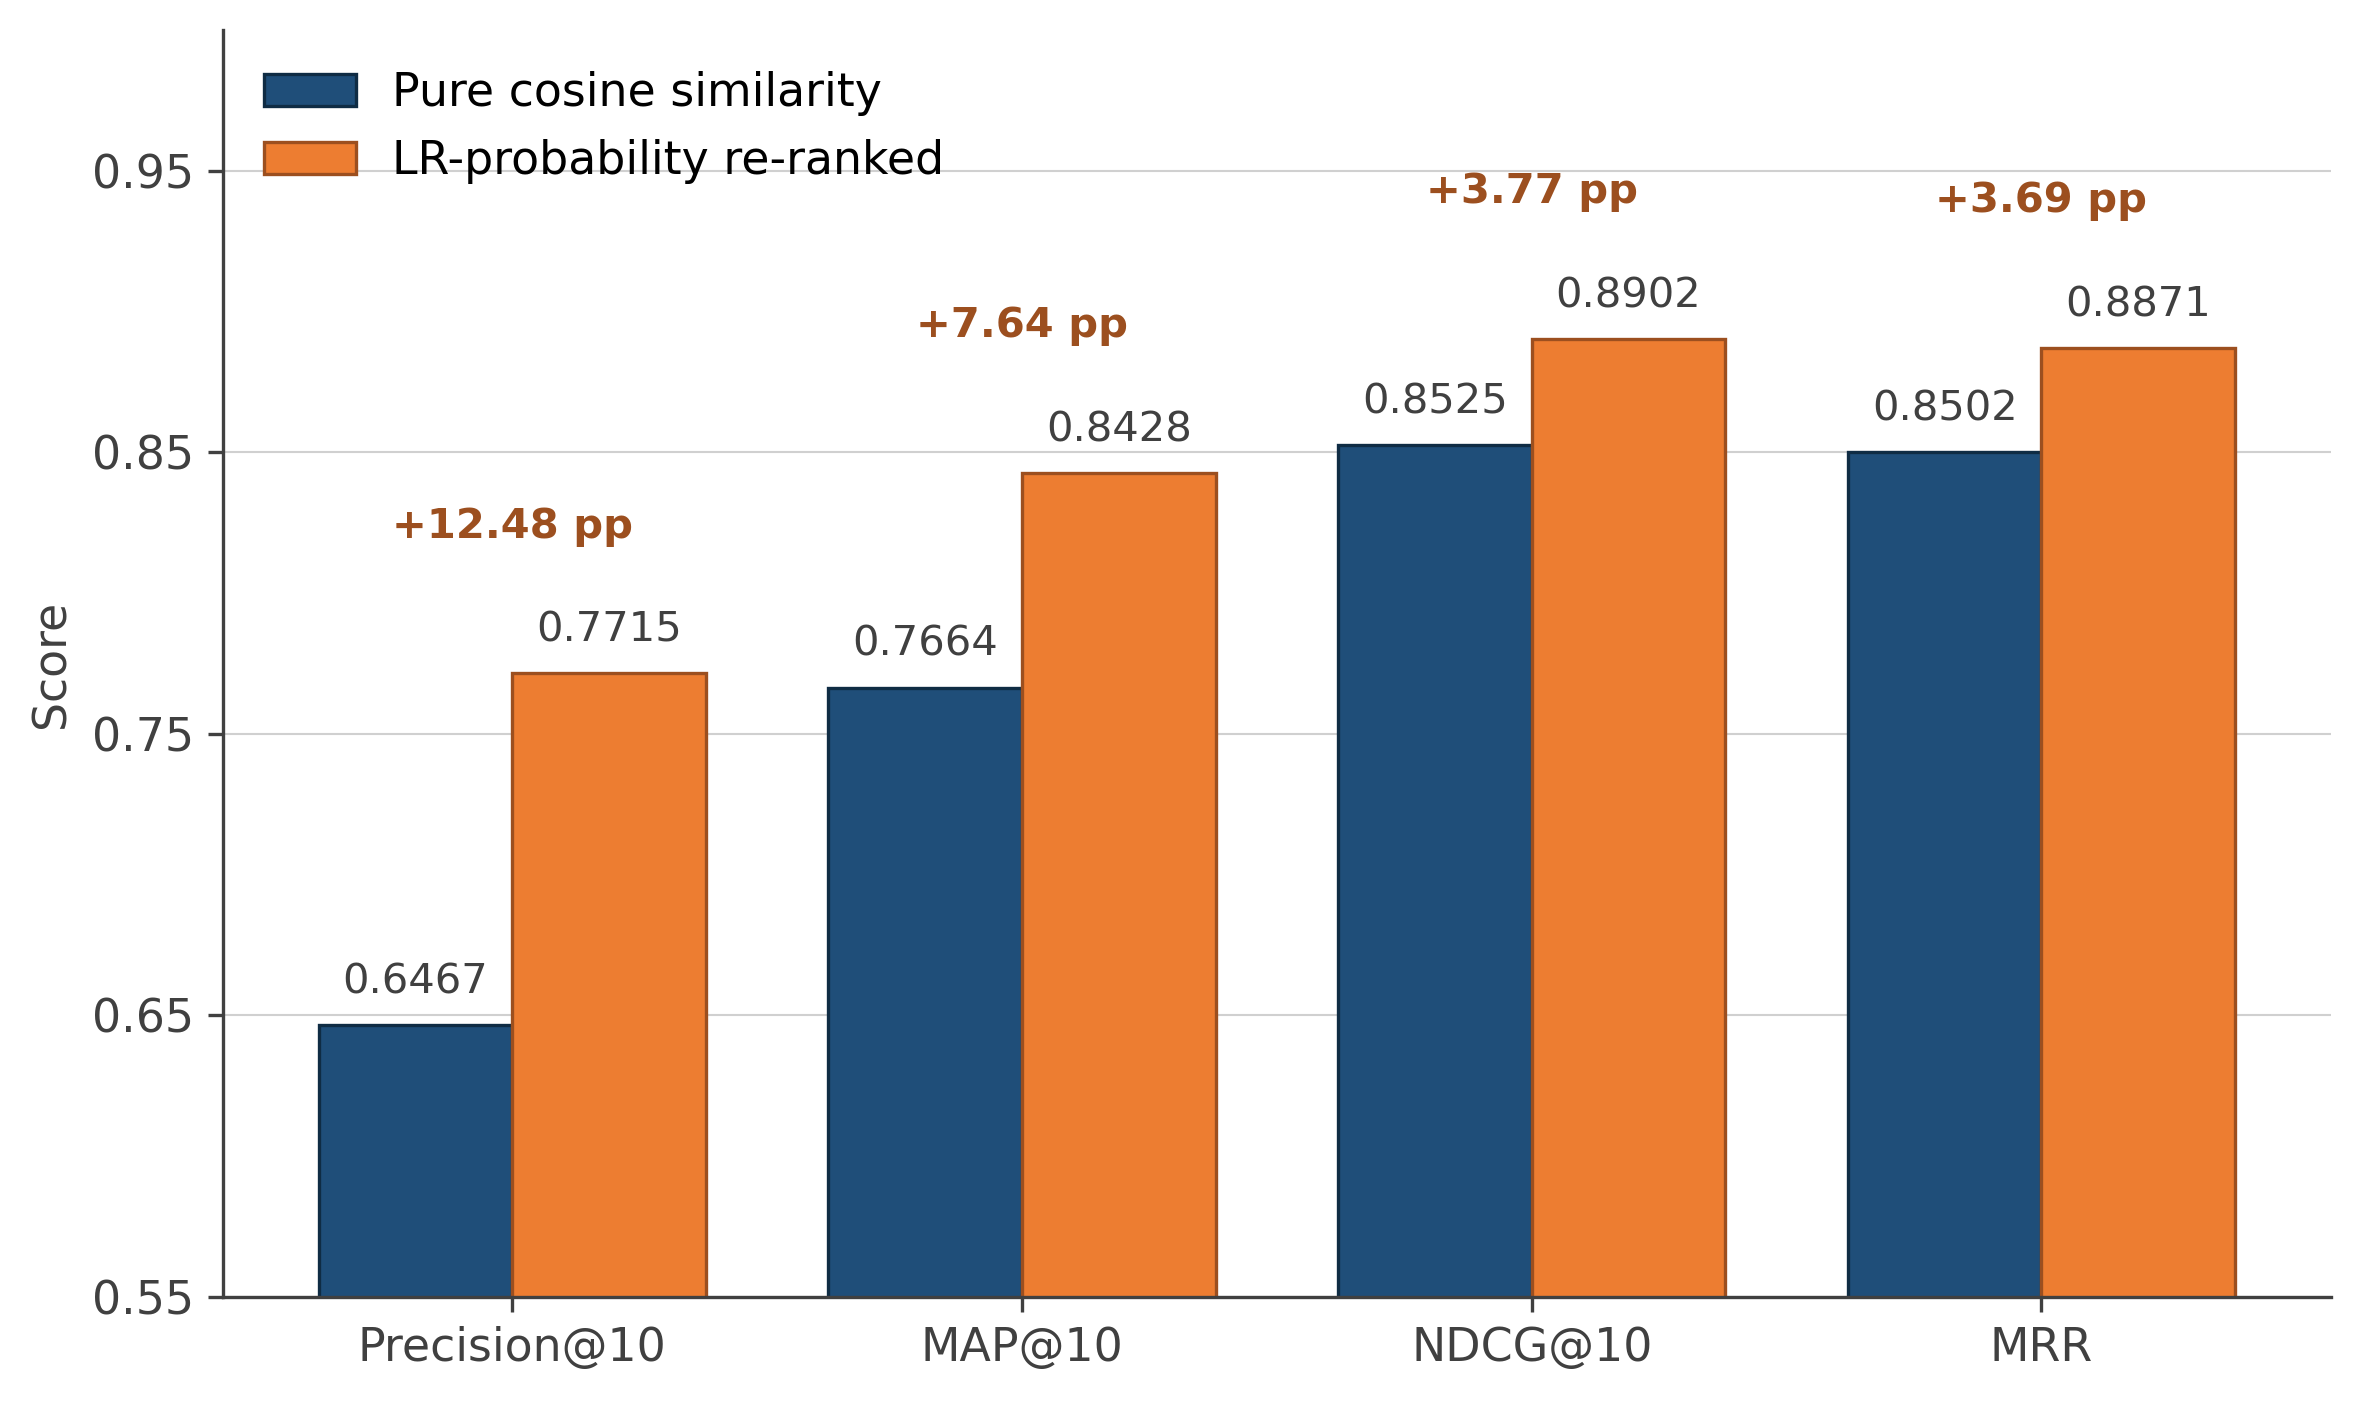

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#404040",
    "axes.labelcolor": "#404040",
    "xtick.color": "#404040",
    "ytick.color": "#404040",
})

metrics  = ["Precision@10", "MAP@10", "NDCG@10", "MRR"]
keys     = ["p",            "map",     "ndcg",    "mrr"]

cosine_vals  = [results_A[k] for k in keys]
rerank_vals  = [results_B[k] for k in keys]
deltas       = [b - a for a, b in zip(cosine_vals, rerank_vals)]

x = np.arange(len(metrics))
w = 0.38

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=300)

# Cosine bars (blue)
bars1 = ax.bar(x - w/2, cosine_vals, width=w,
               color="#1F4E79", edgecolor="#0F2C44", linewidth=0.8,
               label="Pure cosine similarity")

# LR-reranked bars (orange)
bars2 = ax.bar(x + w/2, rerank_vals, width=w,
               color="#ED7D31", edgecolor="#9C4F1F", linewidth=0.8,
               label="LR-probability re-ranked")

# Value labels on each bar
for xi, val in zip(x - w/2, cosine_vals):
    ax.text(xi, val + 0.008, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10, color="#404040")
for xi, val in zip(x + w/2, rerank_vals):
    ax.text(xi, val + 0.008, f"{val:.4f}",
            ha="center", va="bottom", fontsize=10, color="#404040")

# Delta annotation centred above each pair
for xi, c, r, d in zip(x, cosine_vals, rerank_vals, deltas):
    top = max(c, r)
    ax.annotate(f"+{d*100:.2f} pp" if d >= 0 else f"{d*100:.2f} pp",
                xy=(xi, top + 0.045),
                ha="center", va="bottom",
                fontsize=10, fontweight="bold",
                color="#9C4F1F")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0.55, 1.00)
ax.set_yticks([0.55, 0.65, 0.75, 0.85, 0.95])
ax.yaxis.grid(True, linestyle="-", linewidth=0.5, color="#D0D0D0", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("Figure6.png", dpi=600, bbox_inches="tight")
plt.show()

In [25]:
# ====================================================================
# Per-class recommendation metrics — stratify Method A and Method B
# results by the query's true class.
# ====================================================================
from collections import defaultdict

LABEL_NAMES = {
    0: "Big Data & Cloud Computing",
    1: "Data Science",
    2: "Robotics",
    3: "Wireless Communication",
    4: "Breast Cancer",
}

def eval_per_class(ranker_fn, method_name):
    per_class = defaultdict(lambda: {"p": [], "map": [],
                                     "ndcg": [], "mrr": []})
    n = X_te.shape[0]
    for i in range(n):
        q_vec   = X_te[i]
        q_class = int(y_te[i])
        sims    = (q_vec @ X_tr.T).toarray().flatten()
        scores  = ranker_fn(sims, i, q_class)
        top_idx = np.argpartition(-scores, K)[:K]
        top_idx = top_idx[np.argsort(-scores[top_idx])]
        rel     = (train_classes[top_idx] == q_class).astype(int)

        per_class[q_class]["p"].append(precision_at_k(rel, K))
        per_class[q_class]["map"].append(average_precision_at_k(rel, K))
        per_class[q_class]["ndcg"].append(ndcg_at_k(rel, K))
        per_class[q_class]["mrr"].append(reciprocal_rank(rel))

    print(f"\n=== {method_name} — per-class metrics ===")
    print(f"{'Query class':<28}  {'P@10':>7}  {'MAP@10':>7}  "
          f"{'NDCG@10':>8}  {'MRR':>7}  {'n':>5}")
    print("-" * 75)
    for c in sorted(per_class.keys()):
        m   = per_class[c]
        n_c = len(m["p"])
        print(f"  {LABEL_NAMES[c]:<26}  "
              f"{np.mean(m['p']):>7.4f}  {np.mean(m['map']):>7.4f}  "
              f"{np.mean(m['ndcg']):>8.4f}  {np.mean(m['mrr']):>7.4f}  "
              f"{n_c:>5d}")

eval_per_class(ranker_cosine,        "Pure cosine similarity")
eval_per_class(ranker_lr_reranked,   "LR-probability re-ranked")


=== Pure cosine similarity — per-class metrics ===
Query class                      P@10   MAP@10   NDCG@10      MRR      n
---------------------------------------------------------------------------
  Big Data & Cloud Computing   0.6170   0.7890    0.8860   0.9268    800
  Data Science                 0.3708   0.5475    0.6829   0.6392    349
  Robotics                     0.6562   0.7637    0.8405   0.8197    400
  Wireless Communication       0.6565   0.7331    0.8260   0.7945    400
  Breast Cancer                0.9275   0.9485    0.9722   0.9674    400

=== LR-probability re-ranked — per-class metrics ===
Query class                      P@10   MAP@10   NDCG@10      MRR      n
---------------------------------------------------------------------------
  Big Data & Cloud Computing   0.7590   0.8677    0.9198   0.9340    800
  Data Science                 0.4917   0.6180    0.7141   0.6896    349
  Robotics                     0.7805   0.8310    0.8752   0.8628    400
  Wireless C